# 09. El Yazısı Rakam Tanıma

**Kategori:** Bilgisayarlı Görü  
**Gerçek veri seti:** scikit-learn Optical Recognition of Handwritten Digits  
**Veri kaynağı:** [https://scikit-learn.org/stable/datasets/toy_dataset.html#digits-dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#digits-dataset)  
**Amaç:** 8×8 gri seviye görüntülerde 0–9 rakamını sınıflandırmak.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Görüntü verisini tanıma

Görüntü tensörü: (1797, 8, 8) | Düzleştirilmiş özellik: (1797, 64)
Piksel aralığı: 0.0 - 16.0


,0,1,2,3,4,5,6,7,8,9
adet,178,182,177,183,181,182,181,179,174,180


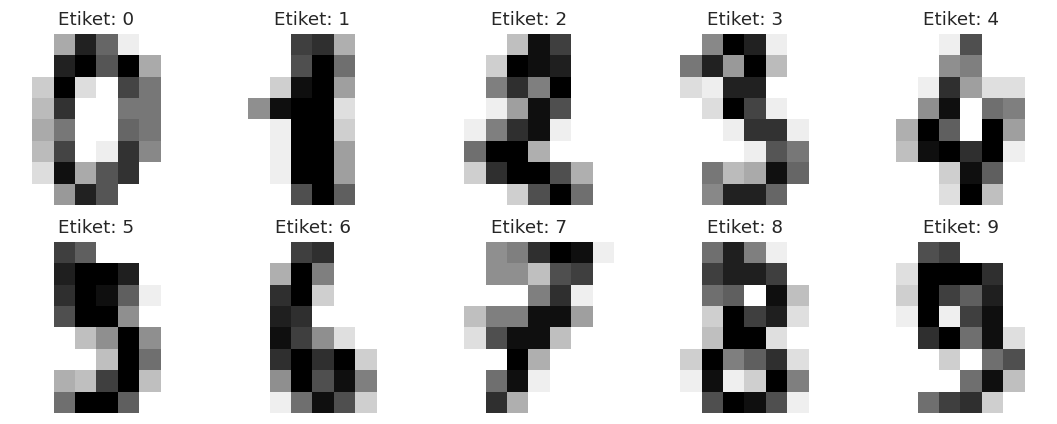

In [2]:
from sklearn.datasets import load_digits
d = load_digits()
print("Görüntü tensörü:", d.images.shape, "| Düzleştirilmiş özellik:", d.data.shape)
print("Piksel aralığı:", d.data.min(), "-", d.data.max())
display(pd.Series(d.target).value_counts().sort_index().to_frame("adet").T)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), d.images[:10], d.target[:10]):
    ax.imshow(image, cmap="gray_r"); ax.set_title(f"Etiket: {label}"); ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Model karşılaştırması

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

X, y = d.data, d.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE
)
candidates = {
    "Lojistik Regresyon": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "RBF-SVM": make_pipeline(StandardScaler(), SVC(C=5, gamma="scale")),
}
fitted = {name: model.fit(X_train, y_train) for name, model in candidates.items()}
scores = pd.Series({name: accuracy_score(y_test, model.predict(X_test))
                    for name, model in fitted.items()}, name="accuracy").sort_values(ascending=False)
display(scores.to_frame().round(4))
best_name = scores.index[0]; best_model = fitted[best_name]; pred = best_model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.97      0.97      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       1.00      0.94      0.97        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



,accuracy
RBF-SVM,0.9806
Lojistik Regresyon,0.9722


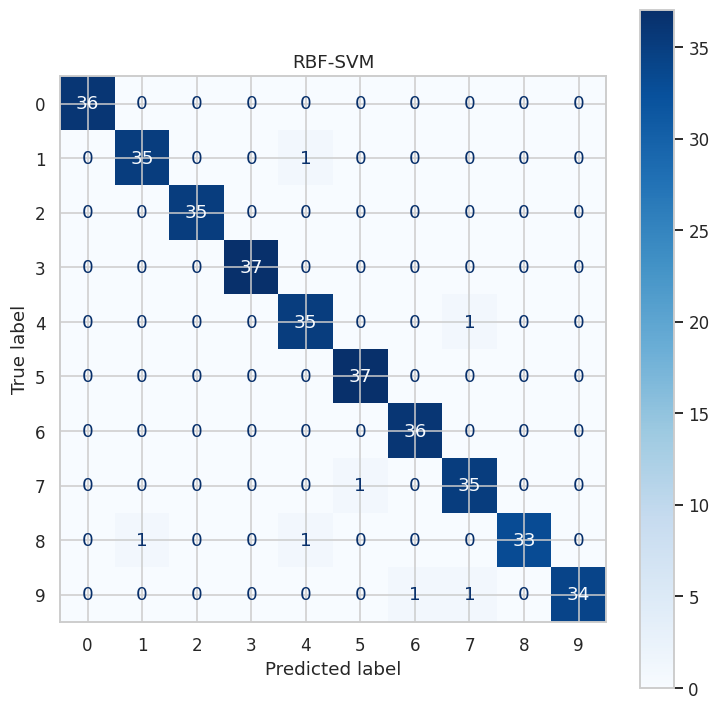

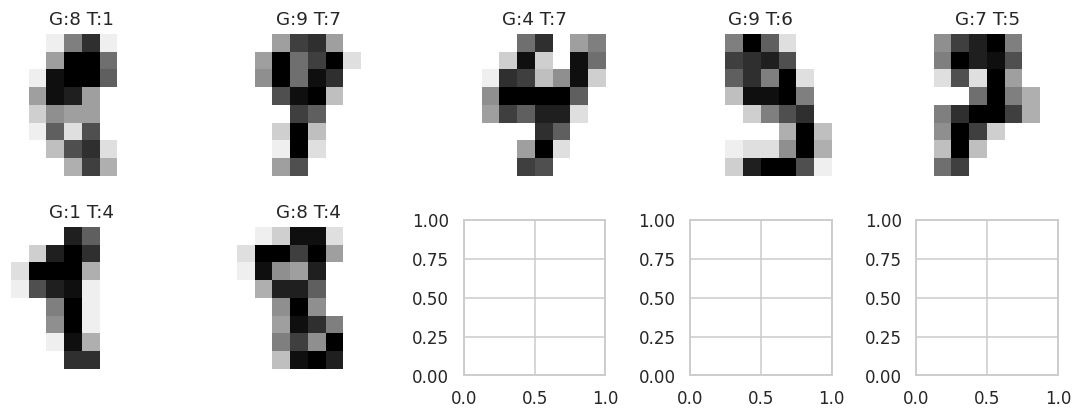

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Blues", ax=ax)
ax.set_title(best_name); plt.show()

errors = np.flatnonzero(pred != np.asarray(y_test))[:10]
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.ravel(), errors):
    ax.imshow(np.asarray(X_test)[idx].reshape(8, 8), cmap="gray_r")
    ax.set_title(f"G:{np.asarray(y_test)[idx]} T:{pred[idx]}"); ax.axis("off")
plt.tight_layout(); plt.show()

In [5]:
joblib.dump({"best_name": best_name, "best_model": best_model,
             "all_models": fitted, "image_shape": (8, 8), "accuracy": scores.to_dict()},
            MODEL_DIR / "09_rakam_tanima.joblib")
json.dump({"best_model": best_name, "accuracy": float(scores.iloc[0])},
          open(RESULT_DIR / "09_rakam_tanima.json", "w"), indent=2)

## Sonuç

Stratified ayrım her rakamın eğitim ve testte benzer oranda kalmasını sağladı. Yalnızca doğruluk
değil, hata matrisi ve yanlış sınıflandırılmış örnekler de incelendi. Bu, modelin hangi rakam
çiftlerini karıştırdığını görmeyi sağlar.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **görüntü pikselleriyle rakam sınıflandırma** biçimindedir.
Bu notebookta **görüntü EDA'sı, iki model, confusion matrix ve yanlış tahmin galerisi** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).